Dataset
   ↓
EDA + Visualizations
   ↓
Train / Test Split
   ↓
GradientBoostingClassifier
   ↓
Probability Predictions
   ↓
Classification Metrics
   ↓
Confusion Matrix
   ↓
ROC Curve
   ↓
Feature Importance
   ↓
Decision Analysis

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1500,
    n_features=12,
    n_informative=7,
    n_redundant=3,
    n_repeated=0,
    n_classes=2,
    weights=[0.55, 0.45],
    flip_y=0.04,
    class_sep=1.2,
    random_state=42
)

feature_names = [
    "income",
    "credit_score",
    "loan_amount",
    "loan_term",
    "employment_years",
    "existing_debt",
    "savings",
    "age",
    "dependents",
    "assets",
    "financial_history",
    "risk_indicator"
]

df = pd.DataFrame(
    X,
    columns=feature_names
)

df["loan_status"] = y

df.head()

,income,credit_score,loan_amount,loan_term,employment_years,existing_debt,savings,age,dependents,assets,financial_history,risk_indicator,loan_status
0,1.078514,-0.726245,1.105831,-0.250054,0.637020,-3.220619,-3.122475,4.899917,0.917037,-1.011359,1.919913,-0.408711,0
1,-0.274118,3.548287,-2.608358,-0.832636,2.164720,-2.808314,1.124898,3.779716,6.050135,-3.582324,1.223397,0.089415,0
2,1.671929,-0.578071,0.373207,-2.279730,1.124267,-2.952044,-1.522350,4.081715,0.772016,-0.976092,1.043732,0.490014,0
3,0.491363,0.806787,-1.824726,-1.906553,1.017160,-3.503510,1.320847,2.250232,1.761500,-0.072331,3.366120,-0.614355,0
4,2.610276,1.905111,-2.204409,2.781872,1.965853,-1.128635,2.474368,1.198702,1.048819,0.986189,1.295703,0.795267,0


In [2]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["loan_status"].value_counts())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1500, 13)

Missing Values:
income               0
credit_score         0
loan_amount          0
loan_term            0
employment_years     0
existing_debt        0
savings              0
age                  0
dependents           0
assets               0
financial_history    0
risk_indicator       0
loan_status          0
dtype: int64

Class Distribution:
loan_status
0    830
1    670
Name: count, dtype: int64

Statistical Summary:
            income  credit_score  loan_amount    loan_term  employment_years  \
count  1500.000000   1500.000000  1500.000000  1500.000000       1500.000000   
mean      0.629768     -0.066882    -1.206446    -0.000299          0.659254   
std       1.705224      1.956141     1.349839     1.021767          1.826018   
min      -4.859977     -8.220478    -5.745118    -3.174749         -5.738951   
25%      -0.594615     -1.357108    -2.044504    -0.715769         -0.598704   
50%       0.675860      0.074199    -1.235129    -0.030925        

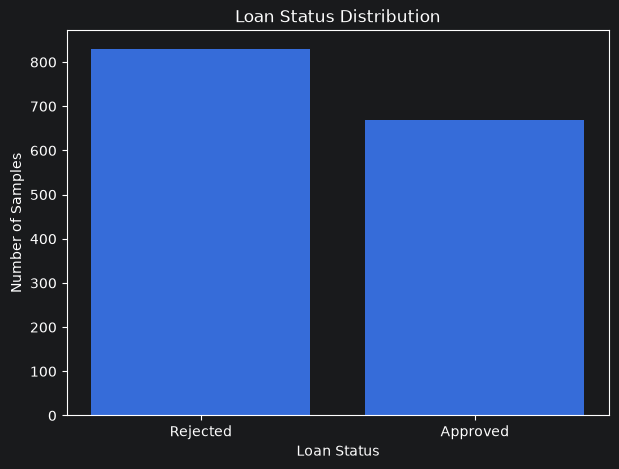

In [3]:
import matplotlib.pyplot as plt

class_counts = df["loan_status"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Rejected", "Approved"],
    class_counts.values
)

plt.xlabel("Loan Status")
plt.ylabel("Number of Samples")
plt.title("Loan Status Distribution")

plt.show()

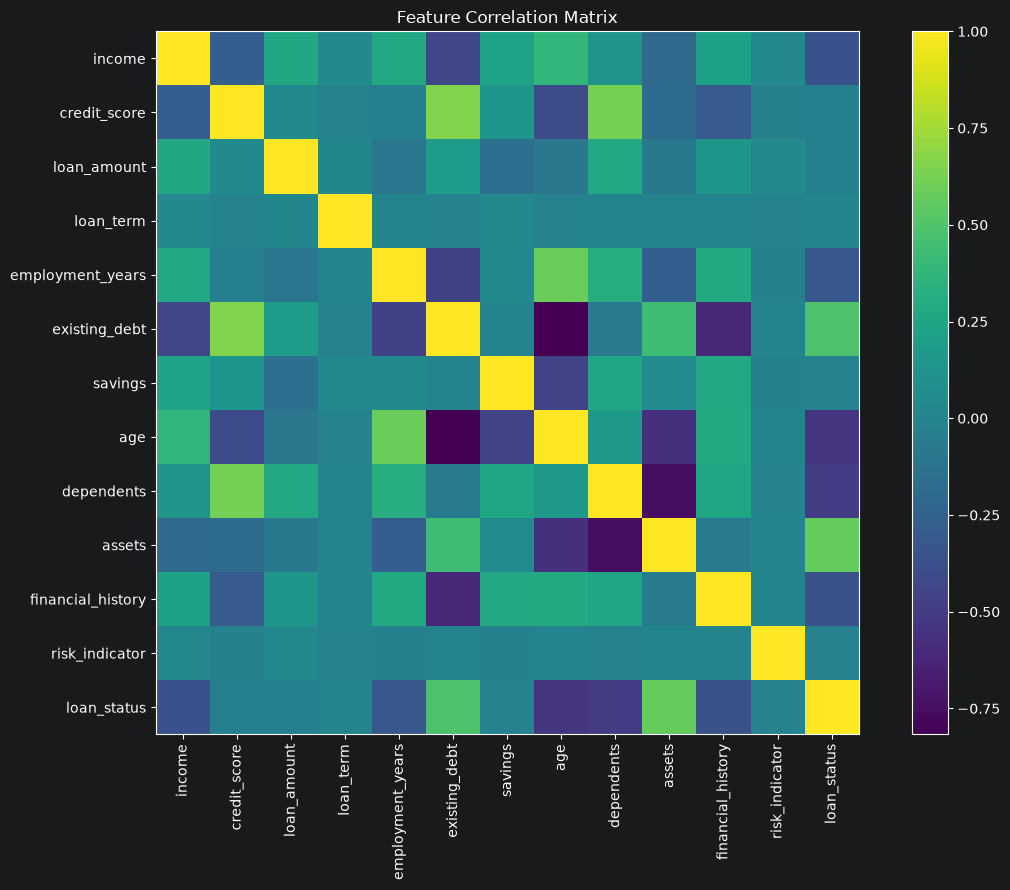

In [4]:
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(12, 9))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

In [5]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1500, 12)
Target Shape: (1500,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Class Ratio:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Ratio:")
print(y_test.value_counts(normalize=True))

Training Shape: (1125, 12)
Testing Shape: (375, 12)

Training Class Ratio:
loan_status
0    0.552889
1    0.447111
Name: proportion, dtype: float64

Testing Class Ratio:
loan_status
0    0.554667
1    0.445333
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

print("\nTraining Class Ratio:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Ratio:")
print(y_test.value_counts(normalize=True))

Training Shape: (1125, 12)
Testing Shape: (375, 12)

Training Class Ratio:
loan_status
0    0.552889
1    0.447111
Name: proportion, dtype: float64

Testing Class Ratio:
loan_status
0    0.554667
1    0.445333
Name: proportion, dtype: float64


In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb_classifier = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

gb_classifier.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

In [10]:
y_pred = gb_classifier.predict(X_test)

y_probability = gb_classifier.predict_proba(X_test)[:, 1]

In [11]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Approved": y_probability
})

results_df.head(15)

,Actual,Predicted,Probability_Approved
0,0,0,0.117039
1,0,1,0.990040
2,1,1,0.980536
3,1,1,0.987318
4,1,1,0.991906
5,0,0,0.102101
6,1,1,0.969759
7,0,0,0.019745
8,1,1,0.734635
9,1,0,0.454582


In [12]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected", "Approved"]
    )
)

              precision    recall  f1-score   support

    Rejected       0.91      0.92      0.91       208
    Approved       0.90      0.89      0.89       167

    accuracy                           0.90       375
   macro avg       0.90      0.90      0.90       375
weighted avg       0.90      0.90      0.90       375



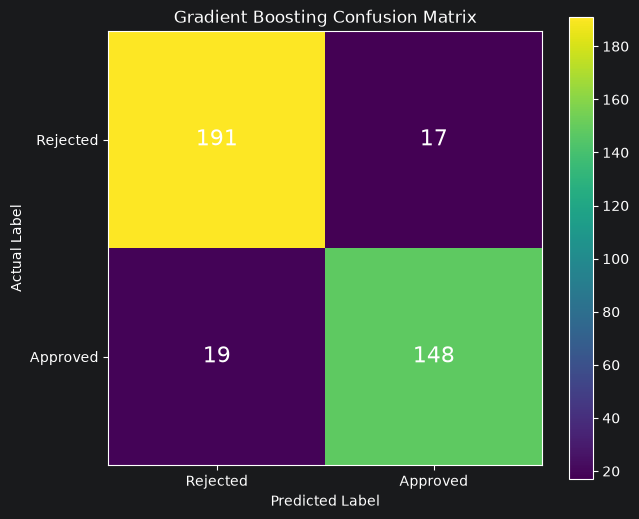

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Rejected", "Approved"]
)

plt.yticks(
    [0, 1],
    ["Rejected", "Approved"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title("Gradient Boosting Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.show()

In [14]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9556080147397512


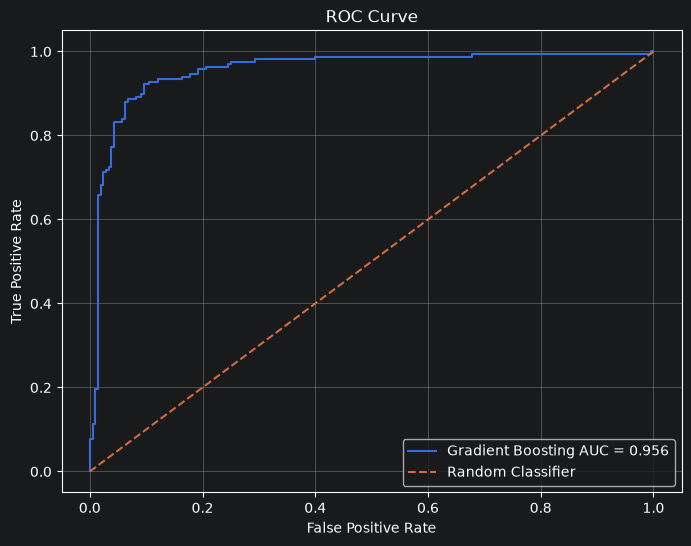

In [15]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
9              assets    0.325060
5       existing_debt    0.129325
7                 age    0.112870
8          dependents    0.099891
10  financial_history    0.078830
4    employment_years    0.076884
0              income    0.050986
6             savings    0.050290
1        credit_score    0.044278
2         loan_amount    0.018151
3           loan_term    0.007957
11     risk_indicator    0.005478


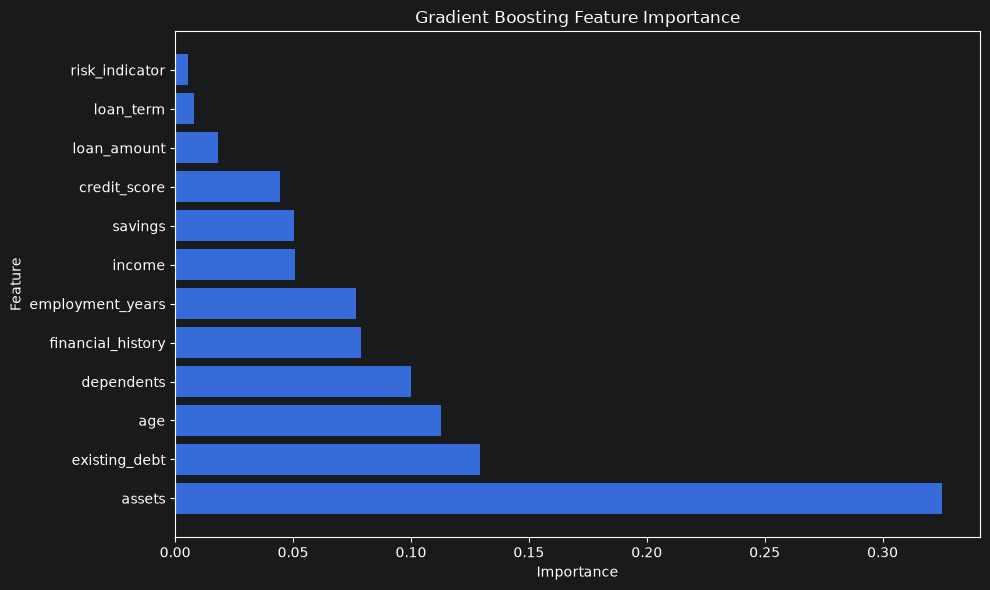

In [17]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Gradient Boosting Feature Importance"
)

plt.tight_layout()

plt.show()

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probability)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9040
Precision: 0.8970
Recall   : 0.8862
F1 Score : 0.8916
ROC-AUC  : 0.9556


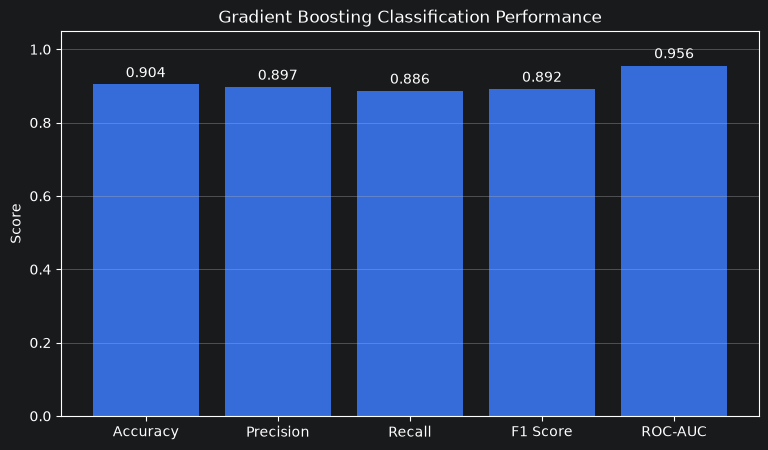

In [19]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": auc
}

plt.figure(figsize=(9, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1.05)

plt.ylabel("Score")
plt.title("Gradient Boosting Classification Performance")

for i, value in enumerate(metrics.values()):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.grid(axis="y")
plt.show()

In [20]:
probability_df = pd.DataFrame({
    "Actual": y_test.values,
    "Probability": y_probability
})

probability_df = probability_df.sort_values(
    "Probability"
)

probability_df.head(20)

,Actual,Probability
159,0,0.007394
265,1,0.007604
52,0,0.008867
266,0,0.009063
216,0,0.009559
306,0,0.009569
174,0,0.010578
154,0,0.010927
63,0,0.011257
61,0,0.011392


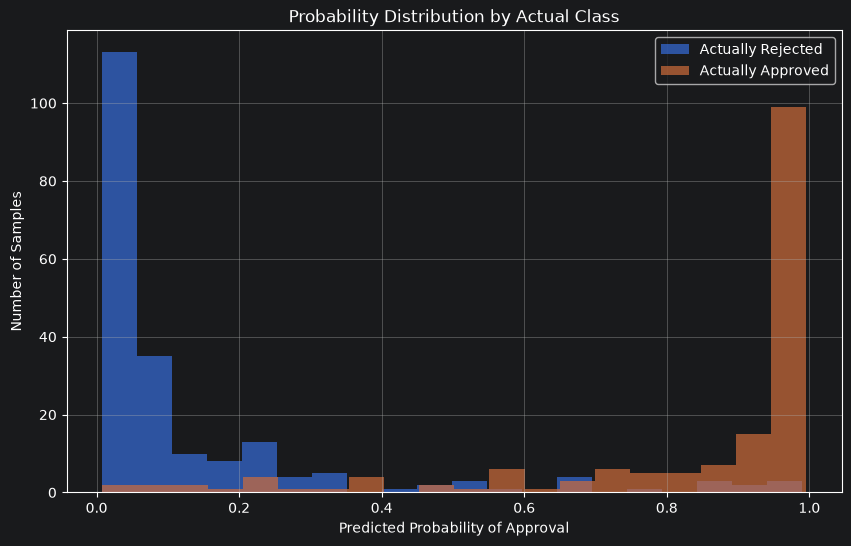

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    y_probability[y_test.values == 0],
    bins=20,
    alpha=0.7,
    label="Actually Rejected"
)

plt.hist(
    y_probability[y_test.values == 1],
    bins=20,
    alpha=0.7,
    label="Actually Approved"
)

plt.xlabel("Predicted Probability of Approval")
plt.ylabel("Number of Samples")

plt.title(
    "Probability Distribution by Actual Class"
)

plt.legend()
plt.grid()

plt.show()

In [22]:
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(
    0.10,
    1.00,
    0.05
)

precision_values = []
recall_values = []
f1_values = []

for threshold in thresholds:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    precision_values.append(
        precision_score(
            y_test,
            predictions,
            zero_division=0
        )
    )

    recall_values.append(
        recall_score(
            y_test,
            predictions,
            zero_division=0
        )
    )

    f1_values.append(
        f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    )

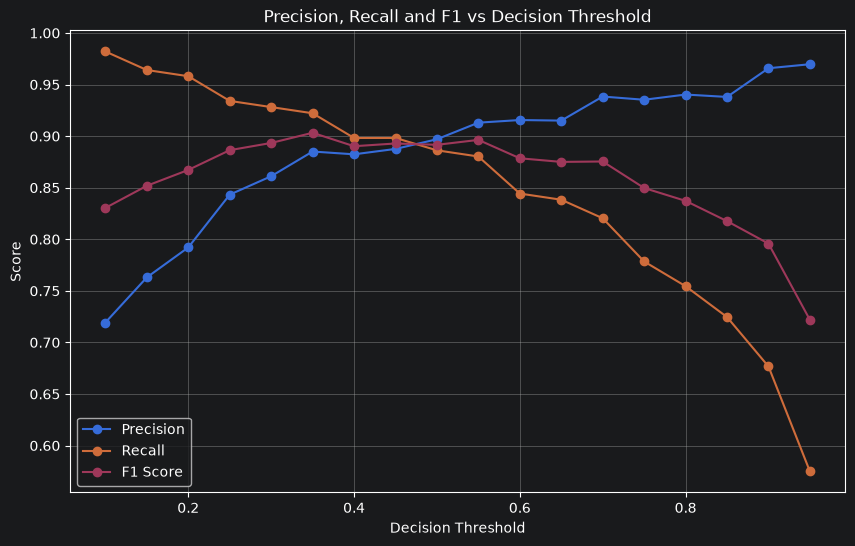

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision_values,
    marker="o",
    label="Precision"
)

plt.plot(
    thresholds,
    recall_values,
    marker="o",
    label="Recall"
)

plt.plot(
    thresholds,
    f1_values,
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1 vs Decision Threshold"
)

plt.legend()
plt.grid()

plt.show()

In [24]:
best_index = np.argmax(f1_values)

best_threshold = thresholds[best_index]
best_f1 = f1_values[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)

Best Threshold: 0.3500000000000001
Best F1 Score: 0.9032258064516129


In [25]:
optimized_predictions = (
    y_probability >= best_threshold
).astype(int)

In [26]:
print(
    classification_report(
        y_test,
        optimized_predictions,
        target_names=[
            "Rejected",
            "Approved"
        ]
    )
)

              precision    recall  f1-score   support

    Rejected       0.94      0.90      0.92       208
    Approved       0.89      0.92      0.90       167

    accuracy                           0.91       375
   macro avg       0.91      0.91      0.91       375
weighted avg       0.91      0.91      0.91       375



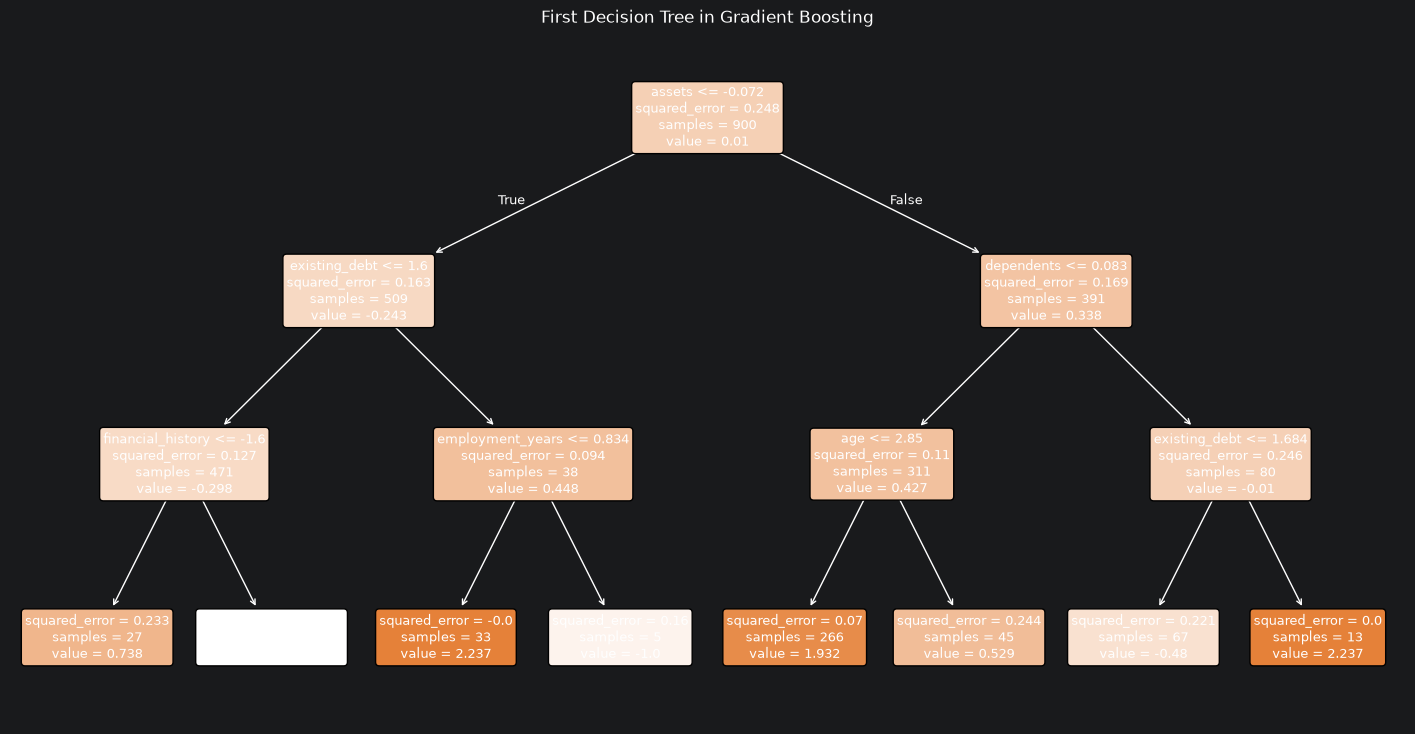

In [27]:
from sklearn.tree import plot_tree

first_tree = gb_classifier.estimators_[0, 0]

plt.figure(figsize=(18, 9))

plot_tree(
    first_tree,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "First Decision Tree in Gradient Boosting"
)

plt.show()

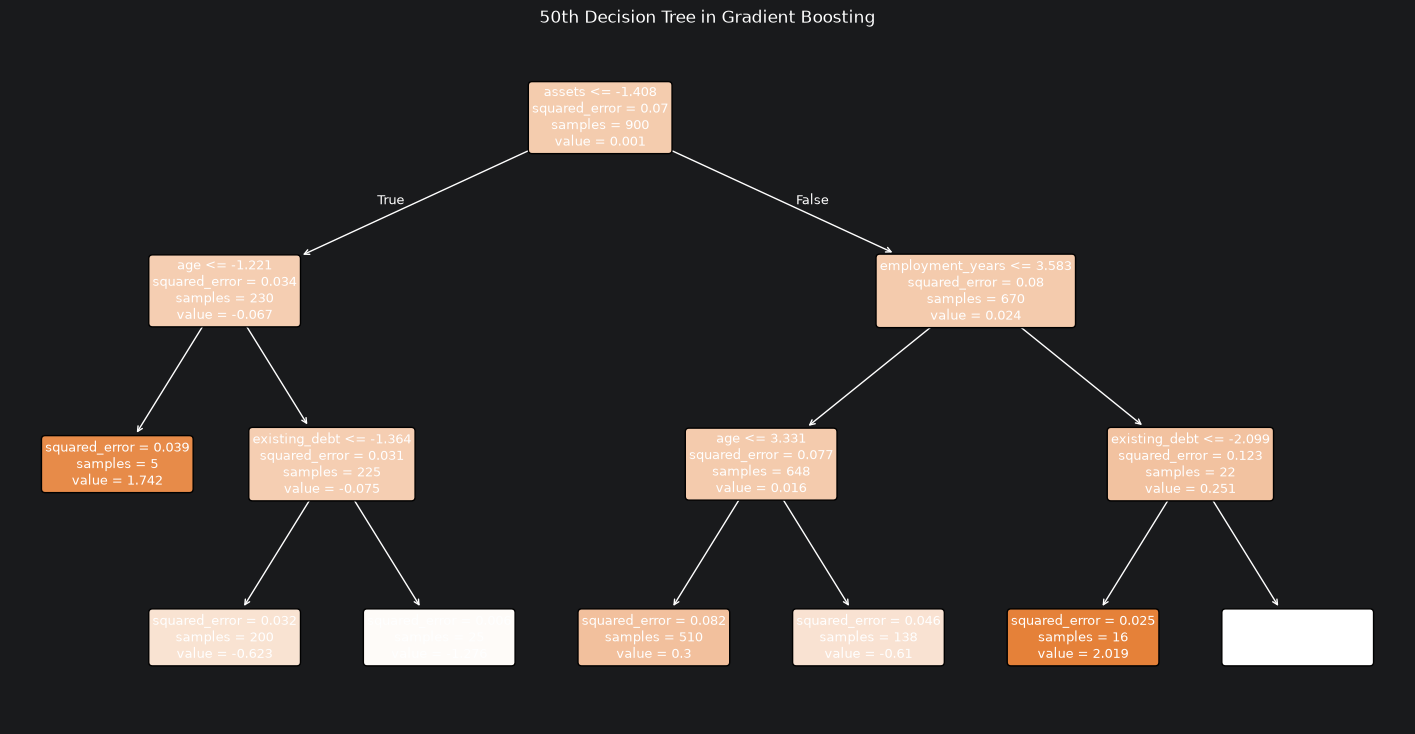

In [28]:
later_tree = gb_classifier.estimators_[49, 0]

plt.figure(figsize=(18, 9))

plot_tree(
    later_tree,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "50th Decision Tree in Gradient Boosting"
)

plt.show()

In [29]:
train_scores = []
test_scores = []

for train_pred, test_pred in zip(
    gb_classifier.staged_predict_proba(X_train),
    gb_classifier.staged_predict_proba(X_test)
):

    train_auc = roc_auc_score(
        y_train,
        train_pred[:, 1]
    )

    test_auc = roc_auc_score(
        y_test,
        test_pred[:, 1]
    )

    train_scores.append(train_auc)
    test_scores.append(test_auc)

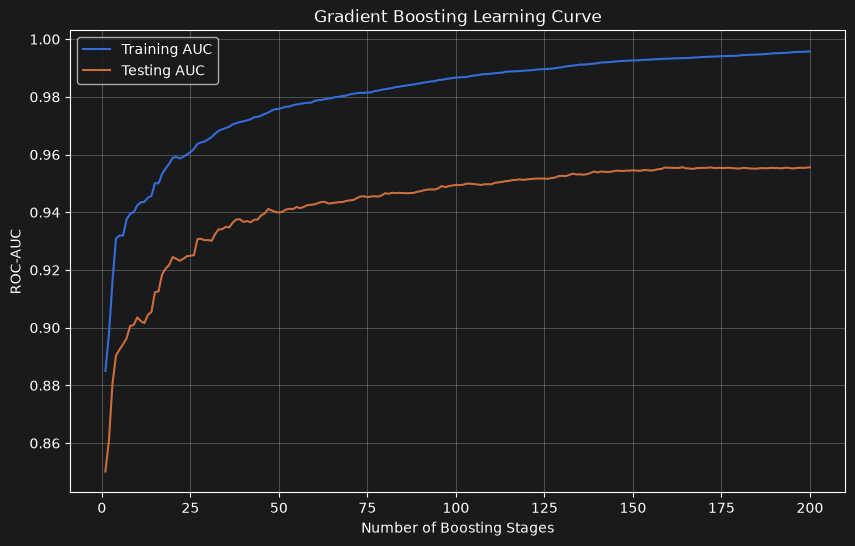

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_scores) + 1),
    train_scores,
    label="Training AUC"
)

plt.plot(
    range(1, len(test_scores) + 1),
    test_scores,
    label="Testing AUC"
)

plt.xlabel("Number of Boosting Stages")
plt.ylabel("ROC-AUC")

plt.title(
    "Gradient Boosting Learning Curve"
)

plt.legend()
plt.grid()

plt.show()